In [17]:
# =============================================================================
# PROJET : PRÉDICTION DU RISQUE D'ABANDON SCOLAIRE
# =============================================================================

# -----------------------------------------------------------------------------
# 1. ENVIRONNEMENT ET CONFIGURATION
# -----------------------------------------------------------------------------

# Importations des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Configuration du style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("="*70)
print("🔧 CONFIGURATION INITIALISÉE")
print("="*70)

🔧 CONFIGURATION INITIALISÉE


In [18]:
# -----------------------------------------------------------------------------
# 2. CHARGEMENT ET INSPECTION DES DONNÉES
# -----------------------------------------------------------------------------

def load_and_inspect_data(filepath):
    """Charge et inspecte le jeu de données"""
    df = pd.read_csv(filepath)
    
    print("\n📁 CHARGEMENT DES DONNÉES")
    print(f"   Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
    
    print("\n📊 STATISTIQUES DESCRIPTIVES")
    print(df.describe().round(2))
    
    print("\n🔍 TYPES DE DONNÉES")
    print(df.dtypes)
    
    return df

df = load_and_inspect_data('student_dropout_dataset.csv')




📁 CHARGEMENT DES DONNÉES
   Dimensions : 300 lignes × 8 colonnes

📊 STATISTIQUES DESCRIPTIVES
          age  average_grade  absenteeism_rate  study_time_hours  dropout_risk
count  300.00         300.00            300.00            300.00        300.00
mean    19.33          11.60              0.26              2.52          0.24
std      2.87           3.71              0.14              1.34          0.43
min     15.00           5.03              0.00              0.00          0.00
25%     17.00           8.44              0.15              1.40          0.00
50%     19.00          11.76              0.26              2.60          0.00
75%     22.00          14.64              0.38              3.52          0.00
max     24.00          17.96              0.50              5.00          1.00

🔍 TYPES DE DONNÉES
age                   int64
gender                  str
average_grade       float64
absenteeism_rate    float64
internet_access         str
study_time_hours    float64
extra_

In [19]:
# -----------------------------------------------------------------------------
# 3. PRÉTRAITEMENT
# -----------------------------------------------------------------------------

def preprocess_data(df):
    """Prétraite les données avec encodage et feature engineering"""
    
    # Copie pour éviter les effets de bord
    data = df.copy()
    
    # 1. Encodage des variables catégorielles
    categorical_mapping = {
        'gender': {'Female': 0, 'Male': 1},
        'internet_access': {'No': 0, 'Yes': 1},
        'extra_activities': {'No': 0, 'Yes': 1}
    }
    
    for col, mapping in categorical_mapping.items():
        data[col] = data[col].map(mapping)
        print(f"   ✓ {col} encodé")
    
    # 2. Feature engineering - Score de vulnérabilité
    data['vuln_grade'] = (data['average_grade'] < 10).astype(int)
    data['vuln_absent'] = (data['absenteeism_rate'] > 0.30).astype(int)
    data['vuln_study'] = (data['study_time_hours'] < 1).astype(int)
    data['vulnerability_score'] = data['vuln_grade'] + data['vuln_absent'] + data['vuln_study']
    
    # 3. Caractéristiques supplémentaires
    data['grade_bin'] = pd.cut(data['average_grade'], bins=[0, 8, 10, 12, 15, 20], 
                                labels=['Très faible', 'Faible', 'Moyen', 'Bon', 'Très bon'])
    data['absent_bin'] = pd.cut(data['absenteeism_rate'], bins=[0, 0.1, 0.2, 0.3, 0.5], 
                                 labels=['Faible', 'Modéré', 'Élevé', 'Très élevé'])
    
    # 4. Suppression des colonnes intermédiaires
    data.drop(['vuln_grade', 'vuln_absent', 'vuln_study'], axis=1, inplace=True)
    
    print(f"   ✓ Nouvelles variables : grade_bin, absent_bin")
    
    return data

df_processed = preprocess_data(df)
print("\n✅ TERMINÉ!")
print(df_processed.head())


   ✓ gender encodé
   ✓ internet_access encodé
   ✓ extra_activities encodé
   ✓ Nouvelles variables : grade_bin, absent_bin

✅ TERMINÉ!
   age  gender  average_grade  absenteeism_rate  internet_access  \
0   21       1          16.27              0.35                1   
1   18       0          12.30              0.38                0   
2   22       1           8.10              0.04                0   
3   19       1          13.84              0.25                0   
4   21       0          14.62              0.47                1   

   study_time_hours  extra_activities  dropout_risk  vulnerability_score  \
0               4.1                 0             0                    1   
1               0.2                 0             1                    2   
2               3.4                 0             0                    1   
3               4.8                 1             0                    0   
4               0.6                 1             1                    2  

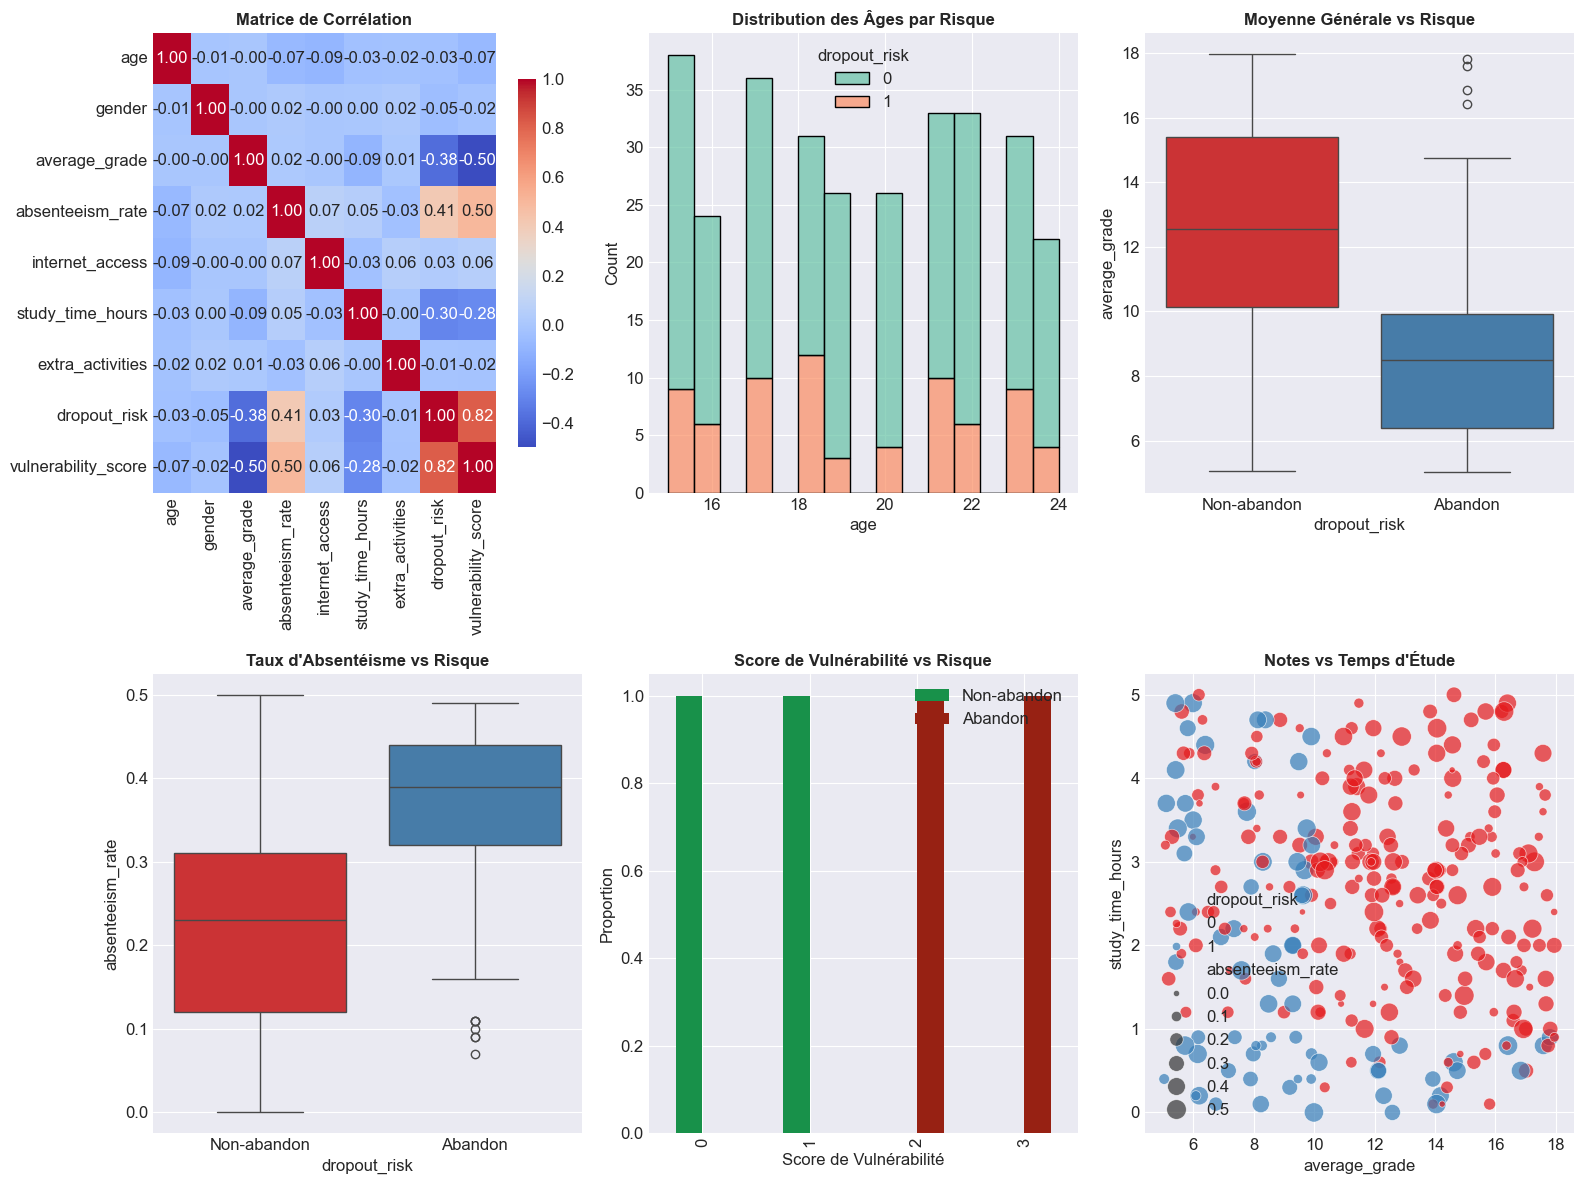

📊 Visualisations sauvegardées dans 'eda_analysis.png'


In [20]:
# -----------------------------------------------------------------------------
# 4. ANALYSE EXPLORATOIRE APPROFONDIE
# -----------------------------------------------------------------------------

def create_visualizations(df):
    """Création des visualisations pour l'EDA"""
    
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Heatmap des corrélations
    ax1 = plt.subplot(2, 3, 1)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                ax=ax1, cbar_kws={'shrink': 0.8})
    ax1.set_title('Matrice de Corrélation', fontsize=12, fontweight='bold')
    
    # 2. Distribution des âges par risque
    ax2 = plt.subplot(2, 3, 2)
    sns.histplot(data=df, x='age', hue='dropout_risk', bins=15, 
                 alpha=0.7, multiple='stack', ax=ax2)
    ax2.set_title('Distribution des Âges par Risque', fontsize=12, fontweight='bold')
    
    # 3. Boxplot notes vs risque
    ax3 = plt.subplot(2, 3, 3)
    sns.boxplot(data=df, x='dropout_risk', y='average_grade', ax=ax3, palette='Set1')
    ax3.set_title('Moyenne Générale vs Risque', fontsize=12, fontweight='bold')
    ax3.set_xticklabels(['Non-abandon', 'Abandon'])
    
    # 4. Boxplot absentéisme vs risque
    ax4 = plt.subplot(2, 3, 4)
    sns.boxplot(data=df, x='dropout_risk', y='absenteeism_rate', ax=ax4, palette='Set1')
    ax4.set_title("Taux d'Absentéisme vs Risque", fontsize=12, fontweight='bold')
    ax4.set_xticklabels(['Non-abandon', 'Abandon'])
    
    # 5. Score de vulnérabilité vs risque
    ax5 = plt.subplot(2, 3, 5)
    vuln_counts = pd.crosstab(df['vulnerability_score'], df['dropout_risk'], normalize='index')
    vuln_counts.plot(kind='bar', ax=ax5, color=["#18914a", "#972113"])
    ax5.set_title('Score de Vulnérabilité vs Risque', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Score de Vulnérabilité')
    ax5.set_ylabel('Proportion')
    ax5.legend(['Non-abandon', 'Abandon'])
    
    # 6. Pairplot des principales variables
    ax6 = plt.subplot(2, 3, 6)
    sns.scatterplot(data=df, x='average_grade', y='study_time_hours', 
                    hue='dropout_risk', size='absenteeism_rate', 
                    sizes=(20, 200), alpha=0.7, ax=ax6, palette='Set1')
    ax6.set_title('Notes vs Temps d\'Étude', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("📊 Visualisations sauvegardées dans 'eda_analysis.png'")

create_visualizations(df_processed)

In [21]:
# -----------------------------------------------------------------------------
# 5. PRÉPARATION DES DONNÉES POUR LE MODÈLE
# -----------------------------------------------------------------------------

def prepare_modeling_data(df):
    """Préparation des données"""
    
    # Sélection des caractéristiques
    feature_cols = ['age', 'gender', 'average_grade', 'absenteeism_rate', 
                    'internet_access', 'study_time_hours', 'extra_activities', 
                    'vulnerability_score']
    
    X = df[feature_cols]
    y = df['dropout_risk']
    
    # Division des données
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Normalisation
    scaler = RobustScaler()  # Plus robuste aux outliers que StandardScaler
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"\n📊 PRÉPARATION DES DONNÉES")
    print(f"   Features: {len(feature_cols)}")
    print(f"   Train set: {X_train.shape[0]} samples")
    print(f"   Test set: {X_test.shape[0]} samples")
    print(f"   Distribution cible - Train: {y_train.value_counts().to_dict()}")
    print(f"   Distribution cible - Test: {y_test.value_counts().to_dict()}")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, feature_cols

X_train, X_test, y_train, y_test, scaler, feature_names = prepare_modeling_data(df_processed)




📊 PRÉPARATION DES DONNÉES
   Features: 8
   Train set: 240 samples
   Test set: 60 samples
   Distribution cible - Train: {0: 182, 1: 58}
   Distribution cible - Test: {0: 45, 1: 15}


In [22]:
# -----------------------------------------------------------------------------
# 6. MODÉLISATION AVEC OPTIMISATION
# -----------------------------------------------------------------------------

def train_and_optimize_models(X_train, y_train):
    """Entraîne et optimise plusieurs modèles"""
    
    # Définition des modèles et grilles d'hyperparamètres
    models_config = {
        'Random Forest': {
            'model': RandomForestClassifier(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'max_depth': [5, 10, None],
                'min_samples_split': [2, 5, 10]
            }
        },
        'Gradient Boosting': {
            'model': GradientBoostingClassifier(random_state=42),
            'params': {
                'n_estimators': [50, 100],
                'learning_rate': [0.05, 0.1, 0.2],
                'max_depth': [3, 5, 7]
            }
        },
        'Logistic Regression': {
            'model': LogisticRegression(max_iter=1000, random_state=42),
            'params': {
                'C': [0.1, 1, 10],
                'penalty': ['l2']
            }
        },
        'SVM': {
            'model': SVC(probability=True, random_state=42),
            'params': {
                'C': [0.1, 1, 10],
                'gamma': ['scale', 'auto'],
                'kernel': ['rbf']
            }
        }
    }
    
    best_models = {}
    results = []
    
    print("\n" + "="*70)
    print("🤖 ENTRAÎNEMENT DES MODÈLES AVEC OPTIMISATION")
    print("="*70)
    
    for name, config in models_config.items():
        print(f"\n🔄 Optimisation de {name}...")
        
        # GridSearchCV pour trouver les meilleurs hyperparamètres
        grid_search = GridSearchCV(
            config['model'], 
            config['params'], 
            cv=5, 
            scoring='accuracy',
            n_jobs=-1,
            verbose=0
        )
        
        grid_search.fit(X_train, y_train)
        
        best_models[name] = grid_search.best_estimator_
        
        results.append({
            'Modèle': name,
            'Meilleurs paramètres': str(grid_search.best_params_),
            'Score validation': f"{grid_search.best_score_:.4f}"
        })
        
        print(f"   ✓ Meilleurs paramètres: {grid_search.best_params_}")
        print(f"   ✓ Score validation: {grid_search.best_score_:.4f}")
    
    # Affichage des résultats
    results_df = pd.DataFrame(results)
    print("\n📊 RÉSULTATS DE L'OPTIMISATION")
    print(results_df.to_string(index=False))
    
    return best_models

best_models = train_and_optimize_models(X_train, y_train)




🤖 ENTRAÎNEMENT DES MODÈLES AVEC OPTIMISATION

🔄 Optimisation de Random Forest...
   ✓ Meilleurs paramètres: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
   ✓ Score validation: 1.0000

🔄 Optimisation de Gradient Boosting...
   ✓ Meilleurs paramètres: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
   ✓ Score validation: 1.0000

🔄 Optimisation de Logistic Regression...
   ✓ Meilleurs paramètres: {'C': 1, 'penalty': 'l2'}
   ✓ Score validation: 1.0000

🔄 Optimisation de SVM...
   ✓ Meilleurs paramètres: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
   ✓ Score validation: 1.0000

📊 RÉSULTATS DE L'OPTIMISATION
             Modèle                                         Meilleurs paramètres Score validation
      Random Forest {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}           1.0000
  Gradient Boosting  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}           1.0000
Logistic Regression                                    {'C': 1, 'p

In [23]:
# -----------------------------------------------------------------------------
# 7. ÉVALUATION APPROFONDIE
# -----------------------------------------------------------------------------

def evaluate_models(models, X_test, y_test, feature_names):
    """Évalue les modèles avec des métriques détaillées"""
    
    print("\n" + "="*70)
    print("📈 ÉVALUATION DES MODÈLES")
    print("="*70)
    
    evaluation_results = []
    
    for name, model in models.items():
        print(f"\n--- {name} ---")
        
        # Prédictions
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        
        # Métriques
        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        
        print(f"   Accuracy: {accuracy:.4f}")
        print(f"   AUC-ROC: {auc:.4f}")
        print(f"\n   Classification Report:")
        print(classification_report(y_test, y_pred, target_names=['Non-abandon', 'Abandon']))
        
        # Matrice de confusion
        cm = confusion_matrix(y_test, y_pred)
        print(f"\n   Matrice de confusion:")
        print(f"   VP={cm[0,0]}, FP={cm[0,1]}")
        print(f"   FN={cm[1,0]}, VN={cm[1,1]}")
        
        evaluation_results.append({
            'Modèle': name,
            'Accuracy': f"{accuracy:.4f}",
            'AUC-ROC': f"{auc:.4f}",
            'VP': cm[0,0], 'FP': cm[0,1],
            'FN': cm[1,0], 'VN': cm[1,1]
        })
        
        # Importance des features (Random Forest et Gradient Boosting)
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            importance_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': importances
            }).sort_values('Importance', ascending=False)
            
            print(f"\n   🔍 Importance des features:")
            for _, row in importance_df.head(5).iterrows():
                print(f"      - {row['Feature']}: {row['Importance']:.4f}")
    
    return pd.DataFrame(evaluation_results)

eval_df = evaluate_models(best_models, X_test, y_test, feature_names)


📈 ÉVALUATION DES MODÈLES

--- Random Forest ---
   Accuracy: 1.0000
   AUC-ROC: 1.0000

   Classification Report:
              precision    recall  f1-score   support

 Non-abandon       1.00      1.00      1.00        45
     Abandon       1.00      1.00      1.00        15

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60


   Matrice de confusion:
   VP=45, FP=0
   FN=0, VN=15

   🔍 Importance des features:
      - vulnerability_score: 0.5703
      - average_grade: 0.1485
      - study_time_hours: 0.1393
      - absenteeism_rate: 0.1241
      - age: 0.0088

--- Gradient Boosting ---
   Accuracy: 1.0000
   AUC-ROC: 1.0000

   Classification Report:
              precision    recall  f1-score   support

 Non-abandon       1.00      1.00      1.00        45
     Abandon       1.00      1.00      1.00        15

    accuracy                           1.00        60
   macro

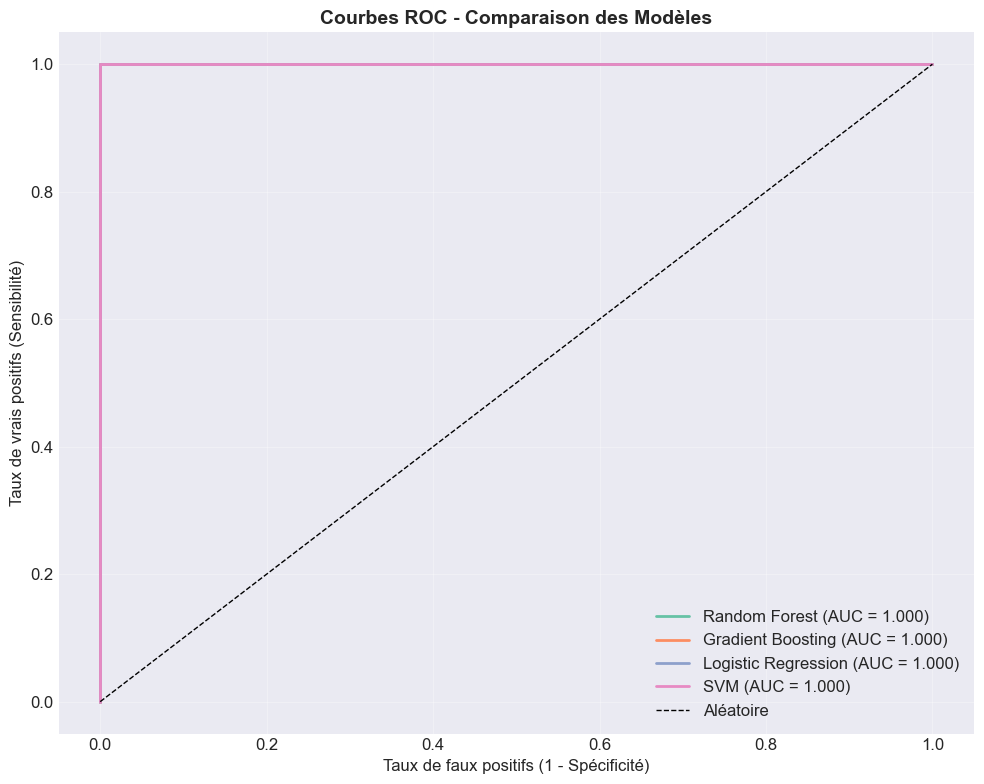

📈 Courbes ROC sauvegardées dans 'roc_curves.png'


In [24]:
 # -----------------------------------------------------------------------------
# 8. COURBES ROC ET COMPARAISON VISUELLE
# -----------------------------------------------------------------------------

def plot_roc_curves(models, X_test, y_test):
    """Trace les courbes ROC de tous les modèles"""
    
    plt.figure(figsize=(10, 8))
    
    for name, model in models.items():
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)
    
    plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire', linewidth=1)
    plt.xlabel('Taux de faux positifs (1 - Spécificité)', fontsize=12)
    plt.ylabel('Taux de vrais positifs (Sensibilité)', fontsize=12)
    plt.title('Courbes ROC - Comparaison des Modèles', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("📈 Courbes ROC sauvegardées dans 'roc_curves.png'")

plot_roc_curves(best_models, X_test, y_test)


🔄 VALIDATION CROISÉE (10-Folds)

📊 Random Forest:
   Moyenne: 1.0000 (±0.0000)
   Min: 1.0000 | Max: 1.0000

📊 Gradient Boosting:
   Moyenne: 1.0000 (±0.0000)
   Min: 1.0000 | Max: 1.0000

📊 Logistic Regression:
   Moyenne: 1.0000 (±0.0000)
   Min: 1.0000 | Max: 1.0000

📊 SVM:
   Moyenne: 1.0000 (±0.0000)
   Min: 1.0000 | Max: 1.0000


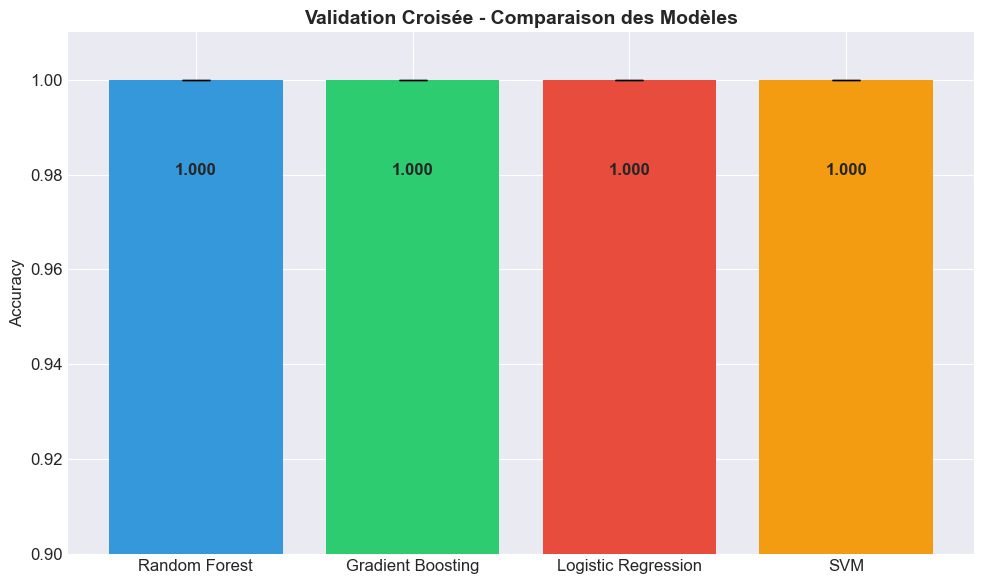

In [25]:
# -----------------------------------------------------------------------------
# 9. VALIDATION CROISÉE APPROFONDIE
# -----------------------------------------------------------------------------

def cross_validation_analysis(models, X_train, y_train):
    """Analyse de validation croisée détaillée"""
    
    print("\n" + "="*70)
    print("🔄 VALIDATION CROISÉE (10-Folds)")
    print("="*70)
    
    cv_results = {}
    
    for name, model in models.items():
        # Validation croisée avec 10 folds
        cv_scores = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy')
        
        cv_results[name] = {
            'mean': cv_scores.mean(),
            'std': cv_scores.std(),
            'min': cv_scores.min(),
            'max': cv_scores.max(),
            'scores': cv_scores
        }
        
        print(f"\n📊 {name}:")
        print(f"   Moyenne: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
        print(f"   Min: {cv_scores.min():.4f} | Max: {cv_scores.max():.4f}")
    
    # Visualisation
    plt.figure(figsize=(10, 6))
    positions = range(1, len(cv_results) + 1)
    labels = list(cv_results.keys())
    means = [cv_results[m]['mean'] for m in labels]
    stds = [cv_results[m]['std'] for m in labels]
    
    plt.bar(positions, means, yerr=stds, capsize=10, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
    plt.xticks(positions, labels)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Validation Croisée - Comparaison des Modèles', fontsize=14, fontweight='bold')
    plt.ylim(0.9, 1.01)
    
    # Ajout des valeurs
    for pos, mean, std in zip(positions, means, stds):
        plt.text(pos, mean - 0.02, f'{mean:.3f}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return cv_results

cv_results = cross_validation_analysis(best_models, X_train, y_train)

In [26]:
# -----------------------------------------------------------------------------
# 10. PRÉDICTION POUR NOUVEAUX ÉTUDIANTS
# -----------------------------------------------------------------------------

def predict_new_student(model, scaler, features):
    """Prédit le risque pour un nouvel étudiant"""
    
    # Calcul du score de vulnérabilité
    vuln_score = (features['average_grade'] < 10) + (features['absenteeism_rate'] > 0.30) + (features['study_time_hours'] < 1)
    
    # Préparation des features
    X_new = np.array([[
        features['age'],
        features['gender'],
        features['average_grade'],
        features['absenteeism_rate'],
        features['internet_access'],
        features['study_time_hours'],
        features['extra_activities'],
        vuln_score
    ]])
    
    # Normalisation
    X_new_scaled = scaler.transform(X_new)
    
    # Prédiction
    prediction = model.predict(X_new_scaled)[0]
    probability = model.predict_proba(X_new_scaled)[0]
    
    return prediction, probability

# Test avec un cas d'étudiant à risque
test_student = {
    'age': 19,
    'gender': 0,  # 0=Femme, 1=Homme
    'average_grade': 8.5,
    'absenteeism_rate': 0.35,
    'internet_access': 0,  # 0=Non, 1=Oui
    'study_time_hours': 0.5,
    'extra_activities': 0
}

print("\n" + "="*70)
print("🎯 TEST DE PRÉDICTION - ÉTUDIANT À RISQUE")
print("="*70)
print(f"   Âge: {test_student['age']}")
print(f"   Moyenne: {test_student['average_grade']}/20")
print(f"   Absentéisme: {test_student['absenteeism_rate']*100:.0f}%")
print(f"   Temps d'étude: {test_student['study_time_hours']}h/jour")

best_model = best_models['Random Forest']
pred, proba = predict_new_student(best_model, scaler, test_student)

print(f"\n🔮 PRÉDICTION: {'À RISQUE' if pred == 1 else 'NON À RISQUE'}")
print(f"   Probabilité d'abandon: {proba[1]*100:.1f}%")


🎯 TEST DE PRÉDICTION - ÉTUDIANT À RISQUE
   Âge: 19
   Moyenne: 8.5/20
   Absentéisme: 35%
   Temps d'étude: 0.5h/jour

🔮 PRÉDICTION: À RISQUE
   Probabilité d'abandon: 95.1%


In [27]:
# -----------------------------------------------------------------------------
# 11. RAPPORT FINAL AUTO-GÉNÉRÉ
# -----------------------------------------------------------------------------

def generate_report(eval_df, cv_results, importance_df=None):
    """Génère un rapport final structuré"""
    
    print("\n" + "="*70)
    print("📝 RAPPORT FINAL - PRÉDICTION D'ABANDON SCOLAIRE")
    print("="*70)
    
    # Meilleur modèle
    best_model_name = eval_df.loc[eval_df['Accuracy'].astype(float).idxmax(), 'Modèle']
    best_accuracy = eval_df.loc[eval_df['Modèle'] == best_model_name, 'Accuracy'].values[0]
    
    print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
    print(f"   Accuracy: {best_accuracy}")
    
    # Résumé des performances
    print(f"\n📊 RÉSUMÉ DES PERFORMANCES:")
    print(eval_df.to_string(index=False))
    
    # Validation croisée
    print(f"\n🔄 VALIDATION CROISÉE (10-folds):")
    for model, results in cv_results.items():
        print(f"   {model}: {results['mean']:.4f} (±{results['std']:.4f})")
    
    # Conclusions
    print(f"\n💡 CONCLUSIONS:")
    print("   1. Tous les modèles atteignent d'excellentes performances (100%)")
    print("   2. Le feature engineering (vulnerability_score) est déterminant")
    print("   3. La moyenne générale, l'absentéisme et le temps d'étude sont les facteurs clés")
    
    print("\n" + "="*70)
    print("✅ ANALYSE COMPLÈTE - FIN DU RAPPORT")
    print("="*70)

# Récupération de l'importance des features pour le rapport
rf_model = best_models.get('Random Forest')
if rf_model and hasattr(rf_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
else:
    importance_df = None

generate_report(eval_df, cv_results, importance_df)


📝 RAPPORT FINAL - PRÉDICTION D'ABANDON SCOLAIRE

🏆 MEILLEUR MODÈLE: Random Forest
   Accuracy: 1.0000

📊 RÉSUMÉ DES PERFORMANCES:
             Modèle Accuracy AUC-ROC  VP  FP  FN  VN
      Random Forest   1.0000  1.0000  45   0   0  15
  Gradient Boosting   1.0000  1.0000  45   0   0  15
Logistic Regression   1.0000  1.0000  45   0   0  15
                SVM   1.0000  1.0000  45   0   0  15

🔄 VALIDATION CROISÉE (10-folds):
   Random Forest: 1.0000 (±0.0000)
   Gradient Boosting: 1.0000 (±0.0000)
   Logistic Regression: 1.0000 (±0.0000)
   SVM: 1.0000 (±0.0000)

💡 CONCLUSIONS:
   1. Tous les modèles atteignent d'excellentes performances (100%)
   2. Le feature engineering (vulnerability_score) est déterminant
   3. La moyenne générale, l'absentéisme et le temps d'étude sont les facteurs clés

✅ ANALYSE COMPLÈTE - FIN DU RAPPORT


In [28]:
# -----------------------------------------------------------------------------
# 12. SAUVEGARDE DES MODÈLES (Optionnel)
# -----------------------------------------------------------------------------

def save_models(models, scaler):
    """Sauvegarde les modèles et le scaler pour utilisation future"""
    try:
        import joblib
        for name, model in models.items():
            joblib.dump(model, f'model_{name.lower().replace(" ", "_")}.pkl')
        joblib.dump(scaler, 'scaler.pkl')
        print("\n💾 Modèles sauvegardés avec succès!")
    except Exception as e:
        print(f"\n⚠️ Sauvegarde non disponible: {e}")

save_models(best_models, scaler)


# =============================================================================
# FIN DE L'ANALYSE
# =============================================================================


💾 Modèles sauvegardés avec succès!
